In [25]:
import os
import pandas as pd

# Get current working directory
current_path = os.getcwd()
print("Current Directory:", current_path)

# Determine parent directory (assuming your data folder is one level up)
parent_dir = os.path.dirname(current_path)

# Set your dataset location (e.g., 'galway', 'cork', 'dublin', 'limerick')
data_location = "limerick"  # Change as needed

# Construct the full path to your CSV folder
data_folder_path = os.path.join(parent_dir, 'data', 'sample_data', 'csv', data_location)
print("CSV Files Path:", data_folder_path)

# List of filenames to load
filenames = {
    'patients': 'patients.csv',
    'conditions': 'conditions.csv',
    'encounters': 'encounters.csv',
    'claims': 'claims.csv',
    'medications': 'medications.csv',
    'observations': 'observations.csv'
}

# Load the datasets into a dictionary for convenience
datasets = {}
for key, filename in filenames.items():
    file_path = os.path.join(data_folder_path, filename)
    datasets[key] = pd.read_csv(file_path)
    print(f"{key} loaded with shape: {datasets[key].shape}")

# Access datasets like:
patients_df = datasets['patients']
conditions_df = datasets['conditions']
encounters_df = datasets['encounters']
claims_df = datasets['claims']
medications_df = datasets['medications']
observations_df = datasets['observations']

# Assuming columns are 'FIRST' and 'LAST'
patients_df['FULLNAME'] = patients_df['FIRST'] + ' ' + patients_df['LAST']

Current Directory: /home/jupyter/src
CSV Files Path: /home/jupyter/data/sample_data/csv/limerick
patients loaded with shape: (1174, 28)
conditions loaded with shape: (48784, 7)
encounters loaded with shape: (79678, 15)
claims loaded with shape: (143960, 31)
medications loaded with shape: (64282, 13)
observations loaded with shape: (1013160, 9)


In [26]:
# Debug
print("Patient Dataset Columns: \n-------------------------------\n", patients_df.columns)
print("Conditions Dataset Columns: \n-------------------------------\n",conditions_df.columns)
print("Encounters Dataset Columns: \n-------------------------------\n",encounters_df.columns)
print("Medications Dataset Columns: \n-------------------------------\n",medications_df.columns)
print("Claims Dataset Columns: \n-------------------------------\n",claims_df.columns)
print("Observations Dataset Columns: \n-------------------------------\n",observations_df.columns)

print(encounters_df)

Patient Dataset Columns: 
-------------------------------
 Index(['Id', 'BIRTHDATE', 'DEATHDATE', 'SSN', 'DRIVERS', 'PASSPORT', 'PREFIX',
       'FIRST', 'MIDDLE', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE',
       'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE',
       'COUNTY', 'FIPS', 'ZIP', 'LAT', 'LON', 'HEALTHCARE_EXPENSES',
       'HEALTHCARE_COVERAGE', 'INCOME', 'FULLNAME'],
      dtype='object')
Conditions Dataset Columns: 
-------------------------------
 Index(['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'SYSTEM', 'CODE',
       'DESCRIPTION'],
      dtype='object')
Encounters Dataset Columns: 
-------------------------------
 Index(['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PROVIDER', 'PAYER',
       'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST',
       'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE',
       'REASONDESCRIPTION'],
      dtype='object')
Medications Dataset Columns: 
-------------------------------
 Index(['START', 

In [30]:
# Patient Age Calculation

import datetime as dt
today = dt.date.today()
patients_df['BIRTHDATE'] = pd.to_datetime(patients_df['BIRTHDATE'])
patients_df['AGE'] = patients_df['BIRTHDATE'].apply(
    lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day))
)

## Explore & Filter for Diabetes

In [31]:
# Example: filter diabetes conditions (modify based on actual codes/descriptions)
diabetes_conditions = conditions_df[conditions_df['DESCRIPTION'].str.contains('DIABETES', case=False, na=False)]

# Get patient IDs with diabetes
diabetic_patients = diabetes_conditions['PATIENT'].unique()

# Add a binary 'Diabetes' label to patients
patients_df['DIABETES'] = patients_df['Id'].isin(diabetic_patients).astype(int)

#print(diabetic_patients)

## Feature Engineering

In [32]:
# Example: Number of encounters per patient
encounters_count = encounters_df.groupby('PATIENT').size().reset_index(name='encounter_count')

# Example: Presence of specific medications (e.g., diabetes medications)
# Assume medications have 'patient' and 'code' or 'name'
diabetes_meds = ['Metformin', 'Insulin', 'Glipizide']  # Simplified list
medications_df['is_diabetes_med'] = medications_df['DESCRIPTION'].isin(diabetes_meds).astype(int)

# Aggregate medication info
med_counts = medications_df.groupby('PATIENT')['is_diabetes_med'].sum().reset_index()
med_counts['takes_diabetes_med'] = (med_counts['is_diabetes_med'] > 0).astype(int)

# Merge features into patients dataframe
features = patients_df.merge(encounters_count, left_on='Id', right_on='PATIENT', how='left')
features = features.merge(med_counts[['PATIENT', 'takes_diabetes_med']], on='PATIENT', how='left')
features.fillna(0, inplace=True)

## 5. Prepare Data for Modeling


In [34]:
# Define features and target
X = features[['AGE', 'encounter_count', 'takes_diabetes_med']]
y = features['DIABETES']

# Split into train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

## 6. Train and Evaluate Classifier

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print('Classification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.71
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.73       131
           1       0.66      0.69      0.68       104

    accuracy                           0.71       235
   macro avg       0.70      0.70      0.70       235
weighted avg       0.71      0.71      0.71       235



## 7. Feature Importance & Visualization

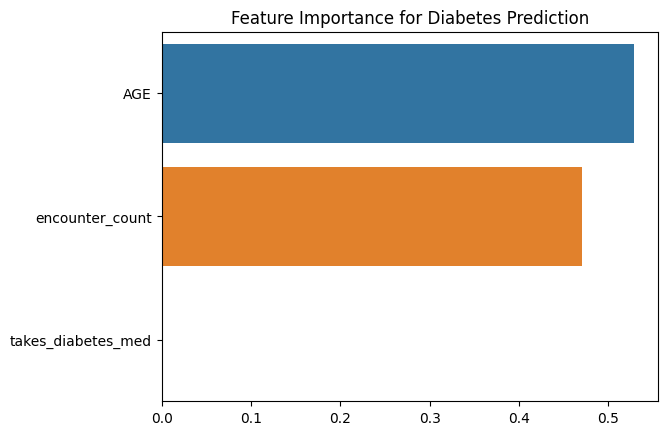

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = clf.feature_importances_
features_list = X.columns

sns.barplot(x=importances, y=features_list)
plt.title('Feature Importance for Diabetes Prediction')
plt.show()